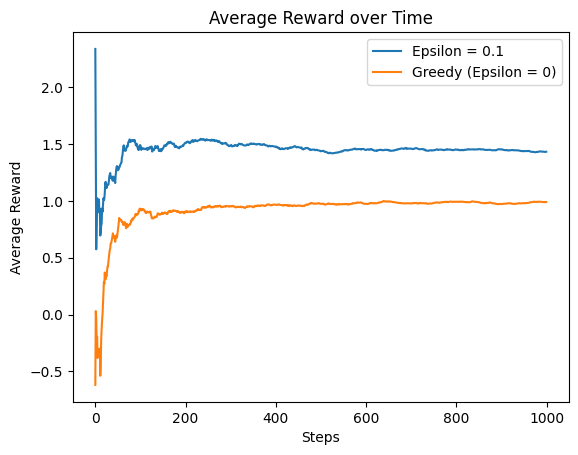

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def simple_bandit_algorithm(k=10, epsilon=0.1, steps=1000):
    # --- INITIALIZE ---
    Q = np.zeros(k) # Q(a) <- 0: Estimated values for each arm
    N = np.zeros(k) # N(a) <- 0: Number of times each arm was pulled
    
    # Environment Setup: The hidden "true" values of the k arms
    q_true = np.random.randn(k) 
    
    # Tracking for visualization
    reward_history = np.zeros(steps)
    
    # --- LOOP FOREVER (or for 'steps') ---
    for i in range(steps):
        # 1. Select Action (A)
        if np.random.rand() < epsilon:
            # Explore: A random action with probability epsilon
            A = np.random.randint(k)
        else:
            # Exploit: argmax Q(a) with probability 1 - epsilon
            # We use np.flatnonzero to find all max values, then random.choice to break ties randomly
            A = np.random.choice(np.flatnonzero(Q == Q.max()))
            
        # 2. Get Reward (R <- bandit(A))
        # The reward is the arm's true mean + some normally distributed noise
        R = np.random.randn() + q_true[A]
        
        # 3. Update Action Count
        N[A] += 1
        
        # 4. Update Value Estimate
        Q[A] += (1.0 / N[A]) * (R - Q[A])
        
        # Record reward for our plot
        reward_history[i] = R
        
    return reward_history, Q, q_true

# --- Run and Visualize ---
steps = 1000
# Run with epsilon = 0.1 (Exploration)
rewards_eps, estimated_q, true_q = simple_bandit_algorithm(epsilon=0.1, steps=steps)
# Run with epsilon = 0 (Pure Greedy / No Exploration)
rewards_greedy, _, _ = simple_bandit_algorithm(epsilon=0.0, steps=steps)

# Plotting the learning curve
plt.plot(np.cumsum(rewards_eps) / (np.arange(steps) + 1), label='Epsilon = 0.1')
plt.plot(np.cumsum(rewards_greedy) / (np.arange(steps) + 1), label='Greedy (Epsilon = 0)')
plt.xlabel('Steps')
plt.ylabel('Average Reward')
plt.legend()
plt.title('Average Reward over Time')
plt.show()

In [11]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from tqdm import trange
import ipywidgets as widgets
from IPython.display import display

class Bandit:
    def __init__(self, k_arm=10, epsilon=0., initial=0., step_size=0.1, sample_averages=False, UCB_param=None,
                 gradient=False, gradient_baseline=False, true_reward=0.):
        self.k = k_arm
        self.step_size = step_size
        self.sample_averages = sample_averages
        self.indices = np.arange(self.k)
        self.time = 0
        self.UCB_param = UCB_param
        self.gradient = gradient
        self.gradient_baseline = gradient_baseline
        self.average_reward = 0
        self.true_reward = true_reward
        self.epsilon = epsilon
        self.initial = initial

    def reset(self):
        self.q_true = np.random.randn(self.k) + self.true_reward
        self.q_estimation = np.zeros(self.k) + self.initial
        self.action_count = np.zeros(self.k)
        self.best_action = np.argmax(self.q_true)
        self.time = 0

    def act(self):
        if np.random.rand() < self.epsilon:
            return np.random.choice(self.indices)

        if self.UCB_param is not None:
            UCB_estimation = self.q_estimation + \
                self.UCB_param * np.sqrt(np.log(self.time + 1) / (self.action_count + 1e-5))
            q_best = np.max(UCB_estimation)
            return np.random.choice(np.where(UCB_estimation == q_best)[0])

        if self.gradient:
            exp_est = np.exp(self.q_estimation)
            self.action_prob = exp_est / np.sum(exp_est)
            return np.random.choice(self.indices, p=self.action_prob)

        q_best = np.max(self.q_estimation)
        return np.random.choice(np.where(self.q_estimation == q_best)[0])

    def step(self, action):
        reward = np.random.randn() + self.q_true[action]
        self.time += 1
        self.action_count[action] += 1
        self.average_reward += (reward - self.average_reward) / self.time

        if self.sample_averages:
            self.q_estimation[action] += (reward - self.q_estimation[action]) / self.action_count[action]
        elif self.gradient:
            one_hot = np.zeros(self.k)
            one_hot[action] = 1
            baseline = self.average_reward if self.gradient_baseline else 0
            self.q_estimation += self.step_size * (reward - baseline) * (one_hot - self.action_prob)
        else:
            self.q_estimation[action] += self.step_size * (reward - self.q_estimation[action])
        return reward

def simulate(runs, time, bandits):
    rewards = np.zeros((len(bandits), runs, time))
    best_action_counts = np.zeros(rewards.shape)
    for i, bandit in enumerate(bandits):
        # Disabled tqdm here to prevent terminal spam during rapid interactive updates
        for r in range(runs):
            bandit.reset()
            for t in range(time):
                action = bandit.act()
                reward = bandit.step(action)
                rewards[i, r, t] = reward
                if action == bandit.best_action:
                    best_action_counts[i, r, t] = 1
    mean_best_action_counts = best_action_counts.mean(axis=1)
    mean_rewards = rewards.mean(axis=1)
    return mean_best_action_counts, mean_rewards

def interactive_epsilon_greedy(eps1, eps2, eps3, runs):
    epsilons = [eps1, eps2, eps3]
    bandits = [Bandit(epsilon=eps, sample_averages=True) for eps in epsilons]
    
    time_steps = 1000
    best_action_counts, rewards = simulate(runs, time_steps, bandits)

    plt.figure(figsize=(10, 8))

    plt.subplot(2, 1, 1)
    for eps, reward in zip(epsilons, rewards):
        plt.plot(reward, label=f'$\epsilon$ = {eps}')
    plt.xlabel('Steps')
    plt.ylabel('Average reward')
    plt.legend()

    plt.subplot(2, 1, 2)
    for eps, counts in zip(epsilons, best_action_counts):
        plt.plot(counts * 100, label=f'$\epsilon$ = {eps}')
    plt.xlabel('Steps')
    plt.ylabel('% Optimal action')
    plt.legend()

    plt.tight_layout()
    plt.show()

# Set up the UI sliders
widgets.interact(
    interactive_epsilon_greedy,
    eps1=widgets.FloatSlider(value=0.0, min=0.0, max=0.5, step=0.01, description='Epsilon 1:'),
    eps2=widgets.FloatSlider(value=0.1, min=0.0, max=0.5, step=0.01, description='Epsilon 2:'),
    eps3=widgets.FloatSlider(value=0.01, min=0.0, max=0.5, step=0.01, description='Epsilon 3:'),
    runs=widgets.IntSlider(value=200, min=10, max=1000, step=10, description='Runs:')
);

interactive(children=(FloatSlider(value=0.0, description='Epsilon 1:', max=0.5, step=0.01), FloatSlider(value=…

In [14]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import ipywidgets as widgets
from IPython.display import display

class Bandit:
    def __init__(self, k_arm=10, epsilon=0., initial=0., step_size=0.1, sample_averages=False, UCB_param=None,
                 gradient=False, gradient_baseline=False, true_reward=0.):
        self.k = k_arm
        self.step_size = step_size
        self.sample_averages = sample_averages
        self.indices = np.arange(self.k)
        self.time = 0
        self.UCB_param = UCB_param
        self.gradient = gradient
        self.gradient_baseline = gradient_baseline
        self.average_reward = 0
        self.true_reward = true_reward
        self.epsilon = epsilon
        self.initial = initial

    def reset(self):
        self.q_true = np.random.randn(self.k) + self.true_reward
        self.q_estimation = np.zeros(self.k) + self.initial
        self.action_count = np.zeros(self.k)
        self.best_action = np.argmax(self.q_true)
        self.time = 0

    def act(self):
        if np.random.rand() < self.epsilon:
            return np.random.choice(self.indices)

        if self.UCB_param is not None:
            # UCB Action Selection Formula
            UCB_estimation = self.q_estimation + \
                self.UCB_param * np.sqrt(np.log(self.time + 1) / (self.action_count + 1e-5))
            q_best = np.max(UCB_estimation)
            return np.random.choice(np.where(UCB_estimation == q_best)[0])

        if self.gradient:
            exp_est = np.exp(self.q_estimation)
            self.action_prob = exp_est / np.sum(exp_est)
            return np.random.choice(self.indices, p=self.action_prob)

        q_best = np.max(self.q_estimation)
        return np.random.choice(np.where(self.q_estimation == q_best)[0])

    def step(self, action):
        reward = np.random.randn() + self.q_true[action]
        self.time += 1
        self.action_count[action] += 1
        self.average_reward += (reward - self.average_reward) / self.time

        if self.sample_averages:
            self.q_estimation[action] += (reward - self.q_estimation[action]) / self.action_count[action]
        elif self.gradient:
            one_hot = np.zeros(self.k)
            one_hot[action] = 1
            baseline = self.average_reward if self.gradient_baseline else 0
            self.q_estimation += self.step_size * (reward - baseline) * (one_hot - self.action_prob)
        else:
            self.q_estimation[action] += self.step_size * (reward - self.q_estimation[action])
        return reward

def simulate(runs, time, bandits):
    rewards = np.zeros((len(bandits), runs, time))
    best_action_counts = np.zeros(rewards.shape)
    for i, bandit in enumerate(bandits):
        # Using standard range() instead of tqdm's trange() to prevent terminal spam 
        # when rapidly dragging the interactive sliders.
        for r in range(runs):
            bandit.reset()
            for t in range(time):
                action = bandit.act()
                reward = bandit.step(action)
                rewards[i, r, t] = reward
                if action == bandit.best_action:
                    best_action_counts[i, r, t] = 1
    mean_best_action_counts = best_action_counts.mean(axis=1)
    mean_rewards = rewards.mean(axis=1)
    return mean_best_action_counts, mean_rewards

def interactive_ucb(c1, c2, c3, runs):
    c_values = [c1, c2, c3]
    # Initialize bandits with epsilon=0 but varying UCB_params
    bandits = [Bandit(epsilon=0, UCB_param=c, sample_averages=True) for c in c_values]
    
    time_steps = 1000
    best_action_counts, rewards = simulate(runs, time_steps, bandits)

    plt.figure(figsize=(10, 8))

    plt.subplot(2, 1, 1)
    for c, reward in zip(c_values, rewards):
        plt.plot(reward, label=f'UCB c = {c}')
    plt.xlabel('Steps')
    plt.ylabel('Average reward')
    plt.legend()

    plt.subplot(2, 1, 2)
    for c, counts in zip(c_values, best_action_counts):
        plt.plot(counts * 100, label=f'UCB c = {c}')
    plt.xlabel('Steps')
    plt.ylabel('% Optimal action')
    plt.legend()

    plt.tight_layout()
    plt.show()

# Set up the UI sliders for Jupyter
widgets.interact(
    interactive_ucb,
    c1=widgets.FloatSlider(value=0.0, min=0.0, max=5.0, step=0.1, description='c1 (Greedy):'),
    c2=widgets.FloatSlider(value=1.0, min=0.0, max=5.0, step=0.1, description='c2 (Standard):'),
    c3=widgets.FloatSlider(value=2.0, min=0.0, max=5.0, step=0.1, description='c3 (High):'),
    runs=widgets.IntSlider(value=100, min=10, max=500, step=10, description='Runs:')
);

interactive(children=(FloatSlider(value=0.0, description='c1 (Greedy):', max=5.0), FloatSlider(value=1.0, desc…

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import ipywidgets as widgets

def plot_ucb_fraction(t_val, n_val, c_val):
    # Create an array of time steps from 1 to 1000
    t_array = np.arange(1, 1001)
    
    # Calculate the uncertainty bonus for the selected N, and two reference Ns
    # log(1) is 0, which is fine (sqrt(0) = 0)
    y_user = c_val * np.sqrt(np.log(t_array) / n_val)
    y_ref1 = c_val * np.sqrt(np.log(t_array) / 1)
    y_ref20 = c_val * np.sqrt(np.log(t_array) / 20)
    
    plt.figure(figsize=(10, 6))
    
    # Plot the lines
    plt.plot(t_array, y_ref1, linestyle='--', color='gray', alpha=0.5, label='N = 1 (Rarely pulled)')
    plt.plot(t_array, y_ref20, linestyle='--', color='gray', alpha=0.5, label='N = 20 (Frequently pulled)')
    plt.plot(t_array, y_user, color='blue', linewidth=2, label=f'N = {n_val} (Your selection)')
    
    # Calculate and plot the specific user point
    y_point = c_val * np.sqrt(np.log(t_val) / n_val)
    plt.scatter([t_val], [y_point], color='red', s=100, zorder=5, label=f'Current Value at t={t_val}')
    
    # Formatting the chart
    plt.title('UCB Uncertainty Bonus over Time', fontsize=14)
    plt.xlabel('Total Time Steps (t)', fontsize=12)
    plt.ylabel('Uncertainty Bonus', fontsize=12)
    plt.xlim(1, 1000)
    # Scale Y-axis based on the maximum possible value on the chart
    plt.ylim(0, c_val * np.sqrt(np.log(1000) / 1) + 0.5) 
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    # Display the exact math calculation below the chart
    print(f"--- Math Breakdown ---")
    print(f"At time step t = {t_val}:")
    print(f"1. Numerator (ln(t)): ln({t_val}) = {np.log(t_val):.4f}")
    print(f"2. Divided by Denominator (N = {n_val}): {np.log(t_val) / n_val:.4f}")
    print(f"3. Square root of that: {np.sqrt(np.log(t_val) / n_val):.4f}")
    print(f"4. Multiplied by c ({c_val}): {y_point:.4f}")
    print(f"---")
    print(f"Final Uncertainty Bonus = {y_point:.4f}")

# Set up the UI sliders
widgets.interact(
    plot_ucb_fraction,
    t_val=widgets.IntSlider(value=100, min=1, max=1000, step=10, description='Time (t):'),
    n_val=widgets.IntSlider(value=5, min=1, max=100, step=1, description='Pulls (N):'),
    c_val=widgets.FloatSlider(value=2.0, min=0.1, max=5.0, step=0.1, description='Constant (c):')
);

interactive(children=(IntSlider(value=100, description='Time (t):', max=1000, min=1, step=10), IntSlider(value…